<a href="https://colab.research.google.com/github/Derrickdc02/DIS-Project-Lensed-Galaxy/blob/main/full_sample_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full Sample Train

Here is a test of sampling 32 (320 in the original paper).

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from score_models import ScoreModel, NCSNpp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

OUTPUT_DIR = Path('/home/yd388/rds/hpc-work/DIS-Project-Lensed-Galaxy/outputs/probes_final')

 # ---- Load the trained model (custom train_prior.py checkpoint, NOT a score_models dir) ----
ckpt = torch.load(OUTPUT_DIR / 'latest.pt', map_location='cpu', weights_only=False)
hp = ckpt['score_model_hyperparameters']

net = NCSNpp(**hp)
net.load_state_dict(ckpt['ema_model'])
model = ScoreModel(model=net, sigma_min=hp['sigma_min'], sigma_max=hp['sigma_max'], device=device)
model = model.to(device)
print(f"Loaded EMA at step {ckpt['step']}, sigma_max={model.sde.sigma_max}")

Using device: cuda
Using the Variance Exploding SDE
Loaded EMA at step 350980, sigma_max=263.4


In [ ]:
# ---- Generate unconditional samples ----
N_SAMPLES   = 16
IMAGE_SIZE  = 256        # <-- changed from 128
SAMPLE_STEPS = 4000

with torch.no_grad():
    samples = model.sample(shape=[N_SAMPLES, 1, IMAGE_SIZE, IMAGE_SIZE], steps=SAMPLE_STEPS)
samples = samples.cpu()
print(f'Samples: {samples.shape}, range=[{samples.min():.3f}, {samples.max():.3f}]')

SAMPLES_DIR = OUTPUT_DIR / 'samples'
SAMPLES_DIR.mkdir(exist_ok=True)
torch.save(samples, SAMPLES_DIR / 'unconditional_samples.pt')

Sampling from the prior | t = 0.9 | sigma = 4.6e+01| scale ~ 4.7e+01:  12%|█▏        | 471/4000 [15:40<1:58:43,  2.02s/it]

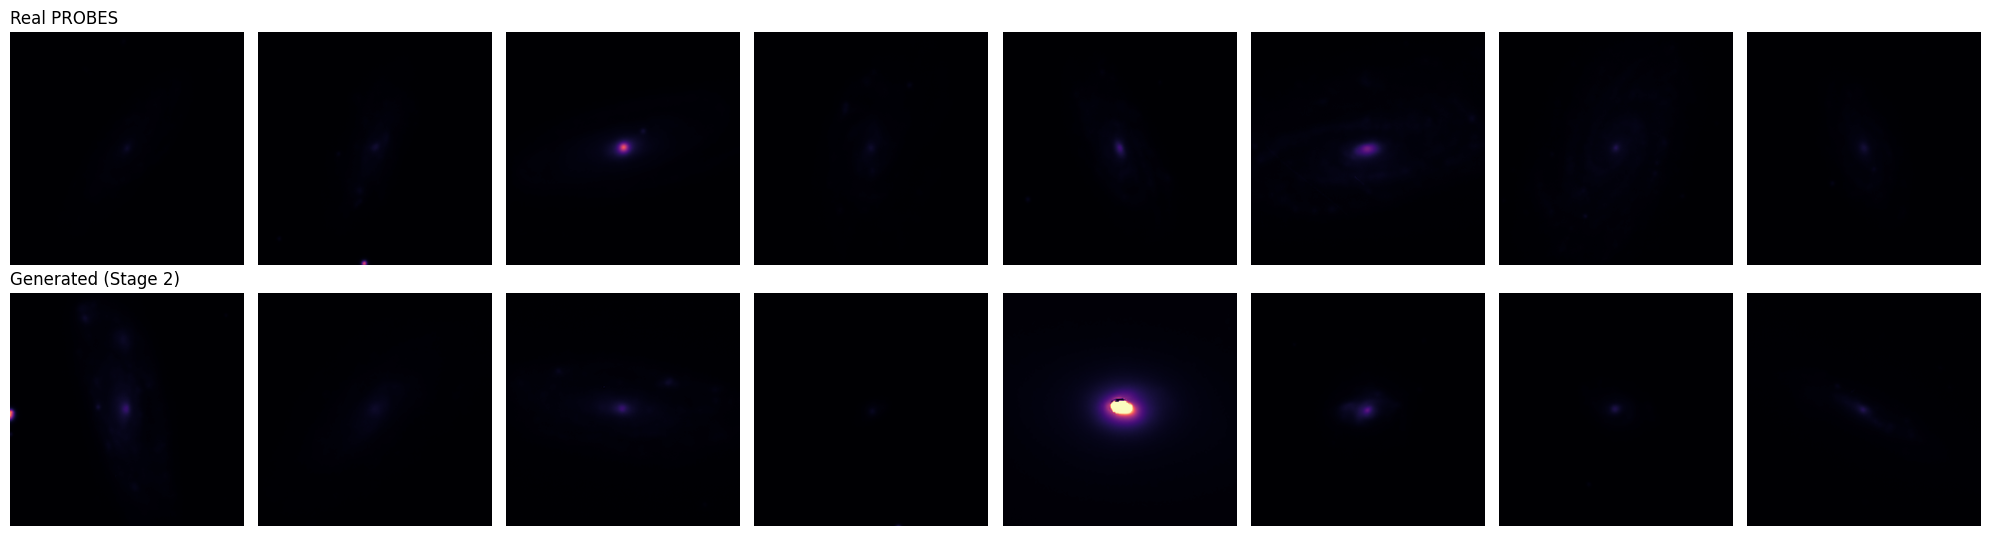

In [ ]:
# Load some real PROBES images for side-by-side comparison
import glob
PROJECT_DIR = Path('/home/yd388/rds/hpc-work/DIS-Project-Lensed-Galaxy')
files = sorted(glob.glob(str(PROJECT_DIR / 'data/gals_gband_norm/*.npy')))[:N_SAMPLES]
assert len(files) > 0, f'No .npy files found under {PROJECT_DIR / "data/gals_gband_norm"}'
real = np.stack([np.load(f)[0] for f in files]).astype(np.float32)
# Resize to IMAGE_SIZE to match
import torch.nn.functional as F
real = F.interpolate(
    torch.from_numpy(real).unsqueeze(1),
    size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False
).squeeze(1).numpy()

# Side-by-side
fig, axes = plt.subplots(2, 8, figsize=(20, 5.5))
for i in range(8):
    axes[0, i].imshow(real[i], cmap='magma', origin='lower', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(samples[i, 0].numpy(), cmap='magma', origin='lower', vmin=-1, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_title('Real PROBES', loc='left', fontsize=12)
axes[1, 0].set_title('Generated (Stage 2)', loc='left', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples' / 'comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---- Caustics forward model + posterior sampler ----
import math
import caustics

PIXELSCALE = 0.04
PIXELS     = IMAGE_SIZE
Z_LENS, Z_SOURCE = 0.5, 1.5

cosmology = caustics.FlatLambdaCDM(name='cosmo')
lens = caustics.SIE(
    cosmology=cosmology, name='lens',
    z_l=Z_LENS, z_s=Z_SOURCE,
    x0=0.0, y0=0.0,
    q=0.7, phi=math.pi / 6, Rein=1.2,
)
source = caustics.Pixelated(
    name='source', x0=0.0, y0=0.0,
    pixelscale=PIXELSCALE, shape=(IMAGE_SIZE, IMAGE_SIZE),
)
sim = caustics.LensSource(
    lens=lens, source=source,
    pixelscale=PIXELSCALE, pixels_x=PIXELS, pixels_y=PIXELS,
    name='sim',
)
sim.to(device)


@torch.no_grad()
def posterior_sample(model, sim, y, sigma_y, steps=2000, n_samples=4):
    """Convolved-likelihood posterior sampler (Adam et al. 2022, eqs. 19, 20)."""
    device = next(model.parameters()).device
    H = W = y.shape[-1]
    sde = model.sde

    t_grid = torch.linspace(1.0, 1e-3, steps + 1, device=device)
    x = sde.prior([n_samples, 1, H, W]).sample().to(device)

    for i in range(steps):
        t_scalar = t_grid[i]
        t_batch = t_scalar.expand(n_samples)
        h = (t_grid[i] - t_grid[i + 1])
        var = sigma_y ** 2 + sde.sigma(t_scalar) ** 2
        g = sde.diffusion(t_batch, x)

        with torch.enable_grad():
            x_req = x.detach().requires_grad_(True)
            preds = torch.stack([sim({'source': {'image': x_req[b, 0]}})
                                 for b in range(n_samples)])
            log_lik = -0.5 * ((y - preds) ** 2).sum() / var
            grad_ll = torch.autograd.grad(log_lik, x_req)[0]

        score_post = model.score(t_batch, x) + grad_ll
        z = torch.randn_like(x)
        x = x + (g ** 2) * score_post * h + g * z * h.sqrt()

    return x.clamp(-1, 1)

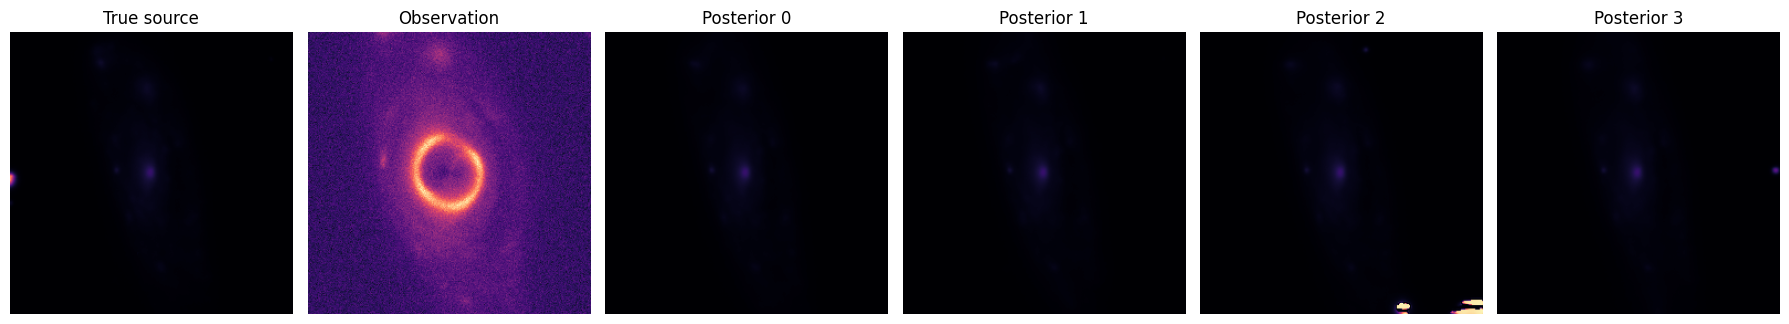

In [ ]:
# Pick a test source
src = samples[0, 0].to(device)

# Lens it (using your Caustics setup from the earlier notebook)
with torch.no_grad():
    lensed = sim({'source': {'image': src}})

# Add noise
NOISE_SIGMA = 0.02
obs = lensed + NOISE_SIGMA * torch.randn_like(lensed)

# Run posterior sampling
post = posterior_sample(model, sim, obs, sigma_y=NOISE_SIGMA,
                        steps=4000, n_samples=4).cpu()

# Plot
fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
axes[0].imshow(src.cpu(), cmap='magma', origin='lower', vmin=-1, vmax=1)
axes[0].set_title('True source')
axes[1].imshow(obs.cpu(), cmap='magma', origin='lower')
axes[1].set_title('Observation')
for k in range(4):
    axes[2+k].imshow(post[k, 0], cmap='magma', origin='lower', vmin=-1, vmax=1)
    axes[2+k].set_title(f'Posterior {k}')
for a in axes: a.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ---- Posterior mean & standard deviation from many draws ----
import time

N_POST = 32     # total posterior draws
CHUNK  = 8      # draws per posterior_sample call
STEPS  = 2000   # 2000 for a sanity check
assert N_POST % CHUNK == 0, 'N_POST must be a multiple of CHUNK'

draws, t0 = [], time.time()
for c in range(N_POST // CHUNK):
    chunk = posterior_sample(
        model, sim,
        y=obs.to(device),
        sigma_y=NOISE_SIGMA,
        steps=STEPS,
        n_samples=CHUNK,
    ).cpu()
    draws.append(chunk)
    print(f'chunk {c+1}/{N_POST//CHUNK} done ({time.time()-t0:.1f}s elapsed)')

post = torch.cat(draws, dim=0)             # (N_POST, 1, H, W)
post_mean = post.mean(dim=0).squeeze(0)    # (H, W)
post_std  = post.std(dim=0).squeeze(0)     # (H, W)

torch.save({'post': post, 'src': src.cpu(), 'obs': obs.cpu()},
           OUTPUT_DIR / 'samples' / 'posterior_draws.pt')

chunk 1/4 done (462.0s elapsed)
chunk 2/4 done (1042.4s elapsed)
chunk 3/4 done (1596.7s elapsed)
chunk 4/4 done (1901.9s elapsed)


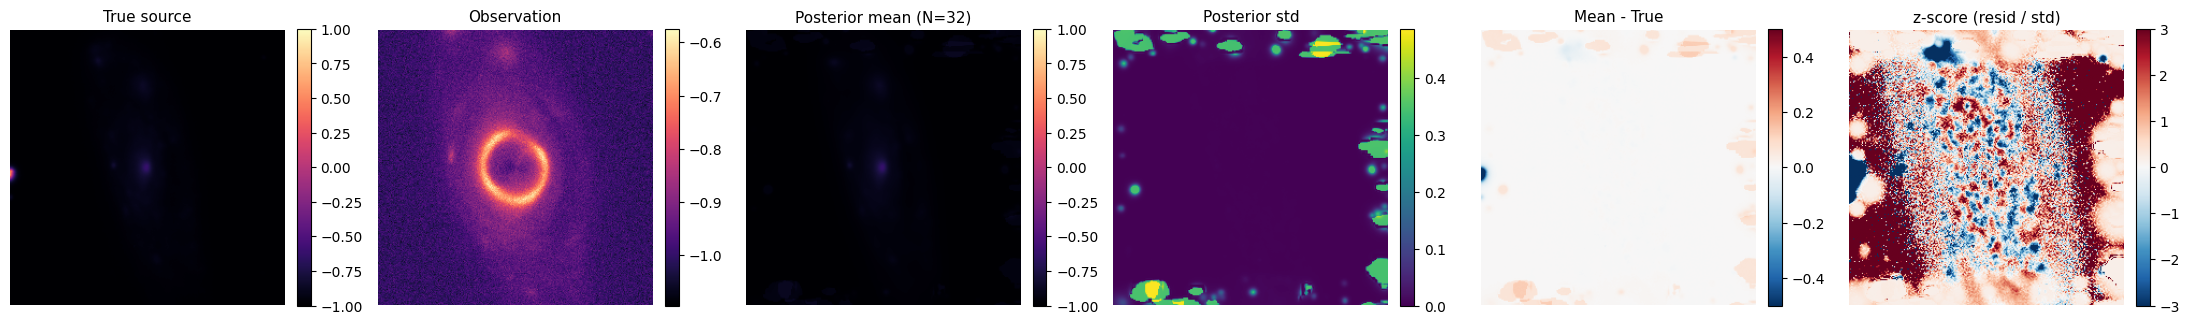

RMSE(posterior mean, true source) = 0.0311
Mean per-pixel posterior std       = 0.0275
Mean |z-score|                     = 163.726   (well-calibrated Gaussian -> sqrt(2/pi) ~ 0.798)


In [ ]:
# ---- Plot: true | obs | mean | std | residual | z-score ----
src_cpu  = src.cpu()
residual = post_mean - src_cpu
zscore   = residual / post_std.clamp(min=1e-6)

panels = [
    ('True source',                src_cpu,   dict(cmap='magma',   vmin=-1, vmax=1)),
    ('Observation',                obs.cpu(), dict(cmap='magma')),
    (f'Posterior mean (N={N_POST})', post_mean, dict(cmap='magma', vmin=-1, vmax=1)),
    ('Posterior std',              post_std,  dict(cmap='viridis')),
    ('Mean - True',                residual,  dict(cmap='RdBu_r', vmin=-0.5, vmax=0.5)),
    ('z-score (resid / std)',      zscore,    dict(cmap='RdBu_r', vmin=-3, vmax=3)),
]
fig, axes = plt.subplots(1, 6, figsize=(22, 3.8))
for ax, (title, img, kw) in zip(axes, panels):
    h = ax.imshow(img.numpy(), origin='lower', **kw)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    fig.colorbar(h, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples' / 'posterior_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

# ---- Numeric calibration check ----
rmse_mean   = (residual ** 2).mean().sqrt().item()
mean_std    = post_std.mean().item()
mean_abs_z  = zscore.abs().mean().item()
print(f'RMSE(posterior mean, true source) = {rmse_mean:.4f}')
print(f'Mean per-pixel posterior std       = {mean_std:.4f}')
print(f'Mean |z-score|                     = {mean_abs_z:.3f}   '
      f'(well-calibrated Gaussian -> sqrt(2/pi) ~ 0.798)')

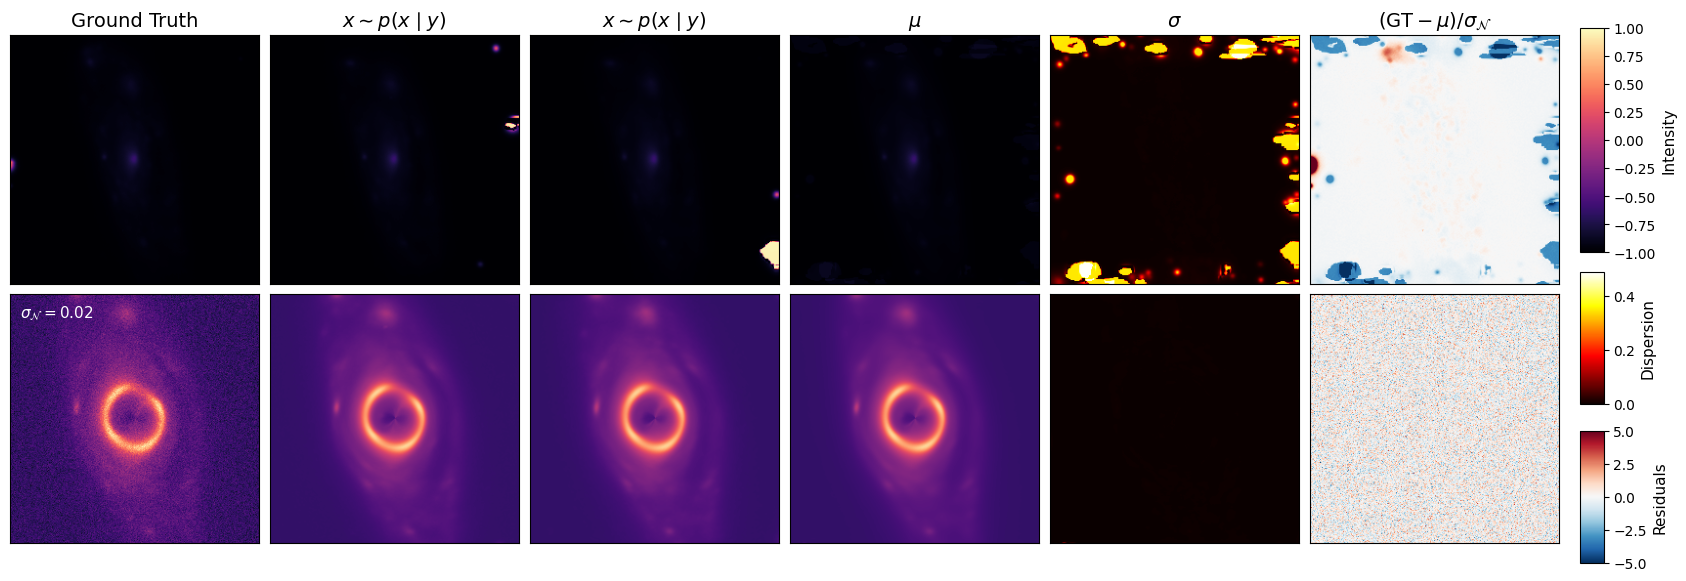

In [ ]:
# ---- Setup and Inference Summary ----
# Columns: Ground Truth | x ~ p(x|y) | x ~ p(x|y) | mu | sigma | (GT - mu)/sigma_N
# Requires `post`, `src`, `obs`, `post_mean`, `post_std`, `NOISE_SIGMA` from earlier cells.
from matplotlib.colors import LogNorm

# Forward-lens every posterior draw (no grad needed for plotting)
with torch.no_grad():
    A_post = torch.stack([
        sim({'source': {'image': post[i, 0].to(device)}})
        for i in range(post.shape[0])
    ]).cpu()                                          # Output shape: (N_POST, H, W)

# Calculate the mean and standard deviation in the lens/image plane
A_post_mean = A_post.mean(dim=0)
A_post_std  = A_post.std(dim=0)

# Randomly select two posterior draws for visual inspection
torch.manual_seed(0)
idx = torch.randperm(post.shape[0])[:2].tolist()
s1, s2 = post[idx[0], 0], post[idx[1], 0]  # Source plane samples
i1, i2 = A_post[idx[0]],  A_post[idx[1]]   # Lens/Image plane samples

# Compute standardized residuals normalized by observation noise (paper convention)
src_resid = (src.cpu() - post_mean) / NOISE_SIGMA
img_resid = (obs.cpu() - A_post_mean) / NOISE_SIGMA

# ---- Display Range Adjustments ----
# Source plane data remains normalized to [-1, 1]
INT_SRC_VMIN, INT_SRC_VMAX = -1.0, 1.0

# Dynamically scale the lens plane to prevent the downsampled/averaged image from looking too dark
INT_IMG_VMAX = max(obs.max().item(), A_post_mean.max().item())
INT_IMG_VMIN = obs.min().item()

STD_VMAX = max(post_std.max().item(), A_post_std.max().item())
RES_VMAX = 5.0                               # Set colorbar limit to +/- 5 sigma_N

# Define keyword arguments for each plot type
intensity_src_kw = dict(cmap='magma',  vmin=INT_SRC_VMIN, vmax=INT_SRC_VMAX, origin='lower')
intensity_img_kw = dict(cmap='magma',  vmin=INT_IMG_VMIN, vmax=INT_IMG_VMAX, origin='lower')
std_kw           = dict(cmap='hot',    vmin=0,            vmax=STD_VMAX,     origin='lower')
res_kw           = dict(cmap='RdBu_r', vmin=-RES_VMAX,    vmax=RES_VMAX,     origin='lower')

# ---- Plotting ----
fig, axes = plt.subplots(2, 6, figsize=(20, 6.6),
                         gridspec_kw={'wspace': 0.04, 'hspace': 0.04})

# --- Row 0: Source Plane Visualization ---
axes[0, 0].imshow(src.cpu(), **intensity_src_kw)
axes[0, 1].imshow(s1,        **intensity_src_kw)
axes[0, 2].imshow(s2,        **intensity_src_kw)
im_int   = axes[0, 3].imshow(post_mean, **intensity_src_kw)  # Primary colorbar target
im_std   = axes[0, 4].imshow(post_std,  **std_kw)
im_res   = axes[0, 5].imshow(src_resid, **res_kw)

# --- Row 1: Lens / Image Plane Visualization ---
axes[1, 0].imshow(obs.cpu(),    **intensity_img_kw)
axes[1, 1].imshow(i1,           **intensity_img_kw)
axes[1, 2].imshow(i2,           **intensity_img_kw)
axes[1, 3].imshow(A_post_mean,  **intensity_img_kw)
axes[1, 4].imshow(A_post_std,   **std_kw)
axes[1, 5].imshow(img_resid,    **res_kw)

# Set descriptive column titles on the top row only
titles = ['Ground Truth', r'$x \sim p(x \mid y)$', r'$x \sim p(x \mid y)$',
          r'$\mu$', r'$\sigma$', r'$(\mathrm{GT}-\mu)/\sigma_{\mathcal{N}}$']
for ax, t in zip(axes[0], titles):
    ax.set_title(t, fontsize=14)

# Print the noise level parameter on the noisy observation panel
axes[1, 0].text(0.04, 0.96, fr'$\sigma_{{\mathcal{{N}}}}={NOISE_SIGMA:g}$',
                transform=axes[1, 0].transAxes, color='white', fontsize=11, va='top')

# Remove clean axes ticks for a seamless grid look
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

# Create space on the right margin and construct stacked colorbars
fig.subplots_adjust(right=0.9)
cax_int = fig.add_axes([0.91, 0.55, 0.012, 0.34])
cax_std = fig.add_axes([0.91, 0.32, 0.012, 0.20])
cax_res = fig.add_axes([0.91, 0.08, 0.012, 0.20])

fig.colorbar(im_int, cax=cax_int).set_label('Intensity',  fontsize=11)
fig.colorbar(im_std, cax=cax_std).set_label('Dispersion', fontsize=11)
fig.colorbar(im_res, cax=cax_res).set_label('Residuals',  fontsize=11)

# Export and display the final diagnostic figure
# plt.savefig(OUTPUT_DIR / 'samples' / 'posterior_grid.png', dpi=200, bbox_inches='tight')
plt.show()